In [155]:
import time
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from line_profiler import profile
import logging
import time
import joblib 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output = "pandas")

from captum.attr import IntegratedGradients, LayerConductance, NeuronConductance
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset, IterableDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter('runs/kags4e7')

import gc
torch.cuda.empty_cache()
gc.collect()

9

In [156]:
class InsDataset(Dataset):
    def __init__(self, dfX, dfy):
        self.dfy = torch.tensor(dfy.values, dtype=torch.long)
        self.dfX = torch.tensor(dfX.values, dtype=torch.float32)
                 
    def __len__(self):
        return len(self.dfy)
    
    @profile
    def __getitem__(self,idx, batch_size):
        features = self.dfX[idx:idx+batch_size,:]
        label    = self.dfy[idx:idx+batch_size]
        return [features, label]

class FastDataLoader:
    def __init__(self, ds, batch_size=32):

        self.ds = ds
        self.dataset_len = ds.__len__()
        self.batch_size = batch_size

        # Calculate # batches
        n_batches, remainder = divmod(self.dataset_len, self.batch_size)
        if remainder > 0:
            n_batches += 1
        self.n_batches = n_batches
        
    def __iter__(self):
        self.i = 0
        return self

    @profile
    def __next__(self):
        if self.i >= self.dataset_len:
            raise StopIteration
        batch = self.ds.__getitem__(self.i, self.batch_size)
        self.i += self.batch_size
        return batch

    def __len__(self):
        return self.n_batches

To do: 
1. Tensorflow board
2. Feature importance
3. fc/bn/do automatic layers
4. Learning rate
5. save best model
6 save model/ load model

In [157]:
class LRScheduler():
    def __init__(self, optimizer, patience=5, min_lr=1e-6, factor=0.8):
  
        self.optimizer = optimizer
        self.patience = patience
        self.min_lr = min_lr
        self.factor = factor
        
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( 
                self.optimizer,
                mode='min',
                patience=self.patience,
                factor=self.factor,
                min_lr=self.min_lr,
            )

    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss)

class EarlyStopper:
    def __init__(self, patience=1, min_delta=0, 
                 save_checkpoint_=False):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        self.save_checkpoint_ = save_checkpoint_
        self.chk_data = None

    def early_stop(self, validation_loss, model=None, optimizer=None,
                   filename='data/models/checkpoint.pt'):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
            if self.save_checkpoint_:
                self.chk_data = {'optimizer': optimizer.state_dict(),
                            'model': model.state_dict()}
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                if self.save_checkpoint_:
                    self.save_checkpoint(filename)
                return True
        return False
    
    def save_checkpoint(self, filename):
        """Saves model when validation loss decrease."""
        torch.save(self.chk_data, filename)


class Model(nn.Module):
    def __init__(self, fc_in_out, dropout_perc, d_out=2):
        super().__init__()
        # Initialize fc layers
        self.linear_layers = nn.ModuleList([nn.Linear(fc_in_out[i],fc_in_out[i+1])
                                        for i in range(len(fc_in_out) - 1)])
        # Output layer
        self.out = nn.Linear(fc_in_out[-1],d_out)
        # Initialize Batch Norm 
        self.batchnorm = nn.ModuleList([nn.BatchNorm1d(s) for s in fc_in_out[1:]])
        # Dropout
        self.dropout = nn.ModuleList([nn.Dropout(p) for p in dropout_perc])

    def forward(self, x):        
        for fc, bn, drop in zip(self.linear_layers, self.batchnorm, self.dropout):
            x = F.silu(fc(x))
            x = bn(x)
            x = drop(x)
        
        x = self.out(x)
        return x       


In [158]:
def load_data(path_load, batch_size):
    df = pd.read_parquet(path_load)
    y = df.pop('Response')
    
    list_int = ['Vehicle_Age','Vintage','Policy_Sales_Channel','Region_Code']
    list_bool = ['Driving_License', 'Previously_Insured', 'Vehicle_Damage', 'Gender']
    list_float = ['Annual_Premium','Age']
    list_target = ['Response']
    
    # Calc imbalance
    class_no = pd.DataFrame(y.to_numpy()).value_counts()/len(y)
    #print(class_no)
    no_features = df.shape[1]
    
    Xtrain, Xtest, ytrain, ytest = train_test_split(df, y, test_size=0.1, stratify=y)
    
    scaler = StandardScaler()
    Xtrain.loc[:,list_float] = scaler.fit_transform(Xtrain.loc[:, list_float])
    Xtest.loc[:,list_float] = scaler.transform(Xtest.loc[:,list_float])
    
    train_dataset = InsDataset(Xtrain, ytrain)
    test_dataset = InsDataset(Xtest, ytest)
    
    trainloader = FastDataLoader(train_dataset, batch_size=batch_size)
    testloader = FastDataLoader(test_dataset, batch_size=batch_size)
    
    return trainloader, testloader, Xtest, ytest, class_no, no_features

# BATCH_SIZE = 1000
# trainloader, testloader, Xtest, ytest, class_no, no_features = \
#     load_data('data/artifacts/train_small.parquet', BATCH_SIZE)
    
BATCH_SIZE = 25000
trainloader, testloader, Xtest, ytest, class_no, no_features = \
    load_data('data/artifacts/train.parquet', BATCH_SIZE)
    

In [159]:
def nested_children(m: torch.nn.Module):
    children = dict(m.named_children())
    output = {}
    if children == {}:
        # if module has no children; m is last child! :O
        return m
    else:
        # look for children from children... to the last child!
        for name, child in children.items():
            try:
                output[name] = nested_children(child)
            except TypeError:
                output[name] = nested_children(child)
    output = flatten(output)
    return output 

def flatten(d, parent_key=''):
    items = []
    for k, v in d.items():
        try:
            items.extend(flatten(v, '%s%s_' % (parent_key, k)).items())
        except AttributeError:
            items.append(('%s%s' % (parent_key, k), v))
    return dict(items)
  
def weight_histograms_linear(writer, step, weights, layer_number):
  flattened_weights = weights.flatten()
  tag = f"layer_{layer_number}"
  writer.add_histogram(tag, flattened_weights, global_step=step, bins='tensorflow')


def weight_histograms(writer, step, model):
  print("Visualizing model weights...")
  # Iterate over all model layers
  layer_dict = nested_children(model)
  for layer_number, (lname, lobj) in enumerate(layer_dict.items()):
    # Compute weight histograms for appropriate layer
    if isinstance(lobj, nn.Linear):
      weights = lobj.state_dict()['weight']
      weight_histograms_linear(writer, step, weights, layer_number)

In [167]:
def train(trainloader, testloader, class_no, no_features, lr, epochs, w_decay, 
          lr_scheduler_=True, proc_device='cpu', verbose=True):
    
    # Device selection
    device = torch.device(proc_device) #('cuda:0' if torch.cuda.is_available() else 'cpu')
    # Def model
    model = Model([no_features, int(0.5*no_features), no_features, 10], [0.1,0.1,0.1]).to(device)
    #print(model)
    # Set metric (criterion) and choose optimizer
    class_weights = torch.FloatTensor(1 - class_no.values).to(device)
    criterion = nn.CrossEntropyLoss(weight = class_weights).to(device)
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=w_decay)
    if lr_scheduler_:
        lr_scheduler = LRScheduler(optimizer, patience=3)

    early_stopper = EarlyStopper(patience=3, min_delta=0,
                    save_checkpoint_=True)
        
    # Training metrics
    train_loss_per_epoch = []
    test_loss_per_epoch = []
    
    for epoch in range(epochs):
        
        model.train()
        running_loss = 0.0
        for i, (features, label) in enumerate(trainloader):
            features = features.to(device)
            label = label.to(device)

            # Reset gradient
            optimizer.zero_grad()
        
            # Forward, backward, optimize
            outputs = model.forward(features)
            loss = criterion(outputs, torch.flatten(label))
            loss.backward()
            optimizer.step()
            
            # Metrics
            running_loss += loss.item()
        
        # Sum single epoch metrics
        train_loss_per_epoch.append(running_loss / (i+1))
        # ############# TENSORBOARD #############
        writer.add_scalar("Train Loss", running_loss/(i+1), epoch)
        if epoch == 0:
            # Write the network graph at epoch 0, batch 0
            writer.add_graph(model, input_to_model=features)
        # ######################################
        running_loss = 0.0
        
        running_test_loss = 0.0
        model.eval()
        for j, (features, label) in enumerate(testloader):
            features = features.to(device)
            label = label.to(device)
            
            y_pred = model.forward(features)
            loss = criterion(y_pred, torch.flatten(label)).detach()
            running_test_loss += loss.item()
            
        # Sum singe epoch test metrics
        validation_loss = running_test_loss / (j+1)
        test_loss_per_epoch.append(validation_loss)
        # ############# TENSORBOARD #############
        writer.add_scalar("Test Loss", running_test_loss/(j+1), epoch)     
        # ######################################
        
        if early_stopper.early_stop(validation_loss, model, optimizer,
                                    filename=f'data/models/checkpoint{epoch-5}.pth'): 
            print(f'Epoch: {epoch}')     
            break
        
        running_test_loss = 0.0
        if lr_scheduler_: lr_scheduler(loss)   
        
        #####################################
        writer.add_scalar('Learning Rate',lr_scheduler.lr_scheduler.get_last_lr()[0], epoch)
            
        if epoch % 10 == 0:
            #Visualize weight histograms
            weight_histograms(writer, epoch, model)        
        #######################################    
        
        
        if verbose:
            if epoch % 10 == 0:
                print(f"Ep: {epoch} Loss Training: {train_loss_per_epoch[-1]} Test: {test_loss_per_epoch[-1]}, learning rate: {lr_scheduler.lr_scheduler.get_last_lr()[0]}")
        else:
            if epoch == (epochs - 1):
                print(f'trained on: {proc_device}')
                print(f"Ep: {epoch} Loss Training: {train_loss_per_epoch[-1]} Test: {test_loss_per_epoch[-1]}")
    
    return model, train_loss_per_epoch, test_loss_per_epoch

LR = 1e-4
w_decay = 2e-3
EPOCHS = 201

trained_model, train_loss_per_epoch, test_loss_per_epoch = \
    train(trainloader, testloader, class_no, no_features, LR, EPOCHS, w_decay)
  
  

Visualizing model weights...
Ep: 0 Loss Training: 0.7004652650959521 Test: 0.6785710136941139, learning rate: 0.0001
Visualizing model weights...
Ep: 10 Loss Training: 0.47388155991772574 Test: 0.4466615832866506, learning rate: 0.0001
Visualizing model weights...
Ep: 20 Loss Training: 0.4422192241053983 Test: 0.43118847621248124, learning rate: 0.0001
Visualizing model weights...
Ep: 30 Loss Training: 0.4394529909972685 Test: 0.42913696486899194, learning rate: 0.0001
Epoch: 37


In [ ]:
def save_model(model, fname=None):
    # add meta data 
    if fname == None:
        fname = f'model_{time.time()}'
    torch.save(model.state_dict(), f'data/models/{fname}.pth')
    return

save_model(trained_model, 'trained_model')




In [168]:
!tensorboard --logdir=runs

TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

I0728 21:38:30.614803 140333451028032 plugin.py:429] Monitor runs begin
Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.17.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C


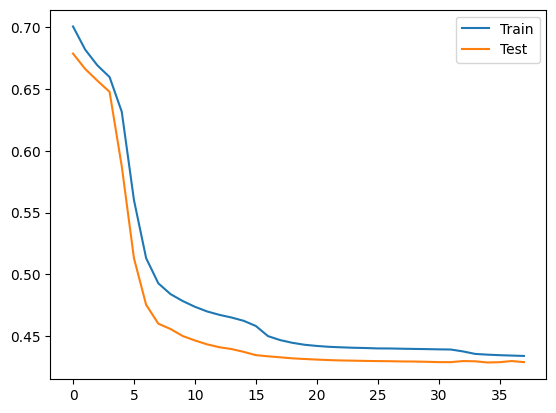

In [169]:
def plot_training(train_loss_per_epoch, test_loss_per_epoch):
    length = len(train_loss_per_epoch)
    plt.figure()
    plt.plot(np.arange(length), train_loss_per_epoch, label="Train")
    plt.plot(np.arange(length), test_loss_per_epoch, label='Test')
    plt.legend()
    plt.show()
    return

plot_training(train_loss_per_epoch, test_loss_per_epoch)

In [170]:
# Predict test set
trained_model.eval()
Xtest_tensor = torch.tensor(Xtest.values, dtype=torch.float)
y_pred = trained_model.forward(Xtest_tensor)
y_hat = torch.argmax(y_pred, 1).detach().cpu().numpy()

proba_layer = nn.Softmax(dim=1)
y_pred_proba = proba_layer(y_pred)
y_pred_proba_arr = y_pred_proba.detach().cpu().numpy()

print(confusion_matrix(ytest, y_hat))
print(classification_report(ytest, y_hat))
print("Accuracy: ", accuracy_score(ytest, y_hat))
print("ROC AUC:", roc_auc_score(ytest, y_pred_proba_arr[:,1]))


[[608342 400632]
 [  3503 138003]]
              precision    recall  f1-score   support

           0       0.99      0.60      0.75   1008974
           1       0.26      0.98      0.41    141506

    accuracy                           0.65   1150480
   macro avg       0.63      0.79      0.58   1150480
weighted avg       0.90      0.65      0.71   1150480

Accuracy:  0.648724880050066
ROC AUC: 0.846777606679681


In [153]:
%who DataFrame
%who torch.Tensor
gc.collect()

Xtest	 imp_df	 
No variables match your requested type.


8317

In [171]:
features = Xtest.columns
test_norm = torch.tensor(Xtest.values, dtype=torch.float32)
test_norm = test_norm.to('cpu')

indices = torch.randperm(len(test_norm))[:1000]
test_data = test_norm[indices]

# Analyze features
trained_model.eval()
ig = IntegratedGradients(trained_model.cpu())
test_data.requires_grad_()
attr, delta = ig.attribute(test_data, target=1, return_convergence_delta=True)
attr = attr.detach().numpy()

importance = np.mean(attr, axis=0)
imp_df = pd.DataFrame(data=importance, index=features, columns=['value'])
display(imp_df.sort_values(by='value'))

,value
Previously_Insured,-1.290121
Age,-0.092330
Annual_Premium,-0.000150
Gender,0.074075
Policy_Sales_Channel,0.080872
Vintage,0.125153
Region_Code,0.158985
Vehicle_Age,0.265495
Vehicle_Damage,0.735005
Driving_License,0.883921
